# Introduction

## Grover’s Algorithm with Noise Analysis

This project demonstrates **Grover’s Search Algorithm**, a quantum algorithm used to find a target element in an unsorted database.

We analyze:
- Ideal (noise-free) performance
- Realistic (noisy) performance

### Objective:
- Search for a target state using Grover’s algorithm
- Compare ideal vs noisy quantum execution
- Understand how noise affects quantum advantage

# 1. Problem Definition (Grover + Noise)

## Problem Setup

We define a small search space using 2 qubits.

### Search Space:
- Total states: \(2^2 = 4\)
- Possible states: `00`, `01`, `10`, `11`

### Target:
We aim to find the state:

 `01` Grover’s algorithm helps amplify the probability of this target state.

In [ ]:
# ==========================================
# STEP 1: Problem Setup
# ==========================================

# Number of qubits
n_qubits = 2

# Target state
target_state = "01"

# Shots
shots = 1024

print("Search Space Size:", 2**n_qubits)
print("Target State:", target_state)

Search Space Size: 4
Target State: 01


# 2. Build Grover Circuit (Ideal)

## Structure of Grover’s Algorithm

Grover’s algorithm consists of four main steps:

1. **Superposition**
   - Create equal probability of all states

2. **Oracle**
   - Mark the target state by flipping its phase

3. **Diffusion Operator**
   - Amplify the probability of the marked state

4. **Measurement**
   - Read the result

### Note:
For a small search space (N = 4), **only one iteration** of Grover is required.

In [ ]:
!pip install qiskit qiskit-aer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit

# Create circuit
qc_grover = QuantumCircuit(2, 2)

# Step 1: Superposition
qc_grover.h([0, 1])

# ----------------------------
# Step 2: Oracle for "01"
# ----------------------------

# Flip qubit 1 (target=01, 2nd qubit=1 already OK, first=0 then flip)
qc_grover.x(1)

# Apply CZ (phase flip on |11>)
qc_grover.cz(0, 1)

# Undo flip
qc_grover.x(1)

# ----------------------------
# Step 3: Diffusion Operator
# ----------------------------

# H gates
qc_grover.h([0, 1])

# X gates
qc_grover.x([0, 1])

# CZ gate
qc_grover.cz(0, 1)

# X gates
qc_grover.x([0, 1])

# H gates
qc_grover.h([0, 1])

# ----------------------------
# Step 4: Measurement
# ----------------------------
qc_grover.measure([0,1], [0,1])

# Draw circuit
qc_grover.draw('text')

┌───┐        ┌───┐┌───┐        ┌───┐┌───┐┌─┐   
q_0: ┤ H ├──────■─┤ H ├┤ X ├──────■─┤ X ├┤ H ├┤M├───
     ├───┤┌───┐ │ ├───┤├───┤┌───┐ │ ├───┤├───┤└╥┘┌─┐
q_1: ┤ H ├┤ X ├─■─┤ X ├┤ H ├┤ X ├─■─┤ X ├┤ H ├─╫─┤M├
     └───┘└───┘   └───┘└───┘└───┘   └───┘└───┘ ║ └╥┘
c: 2/══════════════════════════════════════════╩══╩═
                                               0  1

##  Building the Grover Circuit

We construct a quantum circuit with:
- 2 qubits
- 2 classical bits for measurement

### Superposition:
Apply Hadamard gates to create equal probability distribution.

### Oracle:
Marks the target state (`01`) by applying a phase flip.

### Diffusion:
Amplifies the probability of the marked state.

### Measurement:
Converts quantum results into classical output.

## Oracle Construction

The oracle identifies the target state `01`.

### Steps:
1. Apply X gate to transform `01 → 11`
2. Apply CZ gate to flip phase of `|11⟩`
3. Undo X gate

### Why this works:
This ensures only the target state receives a phase flip, marking it for amplification.

# 3. Ideal Grover Simulation

## Ideal Simulation (No Noise)

We run the Grover circuit using a noise-free simulator.

### Expected Result:
- Target state (`01`) should appear with **100% probability**

### Interpretation:
If only `01` appears, it confirms:
- Oracle is correct
- Diffusion operator is working properly

In [ ]:
from qiskit_aer import AerSimulator

# Simulator
simulator = AerSimulator()

# Run circuit
result = simulator.run(qc_grover, shots=1024).result()

# Get counts
counts_grover = result.get_counts()

print("Grover Ideal Results:", counts_grover)

Grover Ideal Results: {'01': 1024}


# 4. Add Noise to Grover

## Adding Quantum Noise

Real quantum systems are affected by noise.

We simulate noise using a **depolarizing noise model**.

### Noise Applied:
- 10% noise on:
  - Single-qubit gates (H, X)
  - Two-qubit gate (CZ)

### Purpose:
To study how noise impacts quantum algorithm performance.

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer import AerSimulator

# Create noise model
noise_model = NoiseModel()

# Single-qubit noise (H, X gates)
error_1 = depolarizing_error(0.1, 1)
noise_model.add_all_qubit_quantum_error(error_1, ['h', 'x'])

# Two-qubit noise (CZ gate)
error_2 = depolarizing_error(0.1, 2)
noise_model.add_all_qubit_quantum_error(error_2, ['cz'])

# Noisy simulator
noisy_simulator = AerSimulator(noise_model=noise_model)

# Run Grover with noise
noisy_result = noisy_simulator.run(qc_grover, shots=1024).result()

# Get results
noisy_counts_grover = noisy_result.get_counts()

print("Grover Noisy Results:", noisy_counts_grover)

Grover Noisy Results: {'01': 505, '11': 196, '10': 134, '00': 189}


In [ ]:
# measure success probability
success_prob_noisy = noisy_counts_grover.get("01", 0) / 1024

print("Noisy Success Probability:", success_prob_noisy)

Noisy Success Probability: 0.4931640625


## Success Probability Analysis

We compute the probability of correctly finding the target state.

### Results:
- Ideal Success: 1.0
- Noisy Success: ~0.493

### Interpretation:
- Noise reduces Grover’s effectiveness
- Quantum advantage decreases with noise

In [ ]:
# Compare with ideal
success_prob_ideal = counts_grover.get("01", 0) / 1024

print("Ideal Success:", success_prob_ideal)
print("Noisy Success:", success_prob_noisy)

Ideal Success: 1.0
Noisy Success: 0.4931640625


# 5. Final Comparison + Visualization (Grover Ideal vs Noisy)

## Visualization: Ideal vs Noisy Performance

We compare success probabilities using a bar chart.

### Purpose:
- Clearly show performance degradation due to noise

### Insight:
Noise significantly reduces the probability of success.

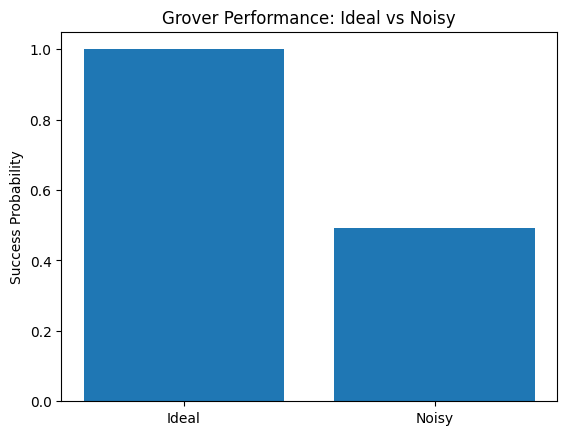

In [ ]:
import matplotlib.pyplot as plt

labels = ['Ideal', 'Noisy']
values = [success_prob_ideal, success_prob_noisy]

plt.bar(labels, values)
plt.ylabel("Success Probability")
plt.title("Grover Performance: Ideal vs Noisy")

plt.show()

# 6. Final Analysis & Conclusion

### Key Observations:
- Grover’s algorithm achieves perfect success in ideal conditions
- Noise introduces incorrect states and reduces success probability

### Important Insight:
Quantum algorithms are highly sensitive to noise, which can significantly degrade performance.

### Key Takeaway:
As noise increases:
- Accuracy decreases
- Quantum advantage weakens

## Conclusion

This project demonstrates the impact of noise on Grover’s algorithm.

### Key Learnings:
- Grover’s algorithm efficiently finds target states in ideal conditions
- Noise disrupts amplitude amplification
- Real-world quantum systems require error mitigation

### Final Thought:
While quantum algorithms offer speed advantages, managing noise is critical for practical quantum computing.